In [5]:
from google.colab import drive
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#  Montar el Drive
drive.mount('/content/drive')

# 1. Cargar el progreso
df_day4 = pd.read_csv('/content/drive/MyDrive/Proyecto_Elecciones_EEUU/df_dia3_final_geolocalizado.csv')

# 2. Recuperar nombres de estados (necesario porque no estaban en el CSV)
fips_to_state = {
    '01': 'Alabama', '04': 'Arizona', '05': 'Arkansas', '06': 'California', '08': 'Colorado',
    '12': 'Florida', '13': 'Georgia', '17': 'Illinois', '18': 'Indiana', '19': 'Iowa',
    '21': 'Kentucky', '22': 'Louisiana', '26': 'Michigan', '27': 'Minnesota', '28': 'Mississippi',
    '29': 'Missouri', '31': 'Nebraska', '34': 'New Jersey', '36': 'New York', '37': 'North Carolina',
    '38': 'North Dakota', '39': 'Ohio', '42': 'Pennsylvania', '45': 'South Carolina', '47': 'Tennessee',
    '48': 'Texas', '51': 'Virginia', '53': 'Washington', '54': 'West Virginia', '55': 'Wisconsin'
}

# Asegurar formato de FIPS y crear state_name
df_day4['county_fips'] = df_day4['county_fips'].astype(str).str.zfill(5)
df_day4['state_code'] = df_day4['county_fips'].str[:2]
df_day4['state_name'] = df_day4['state_code'].map(fips_to_state)

# 3. Crear porcentajes de etnicidad
etnias = ['White', 'Hispanic', 'Black', 'Native', 'Asian']
for etnia in etnias:
    df_day4[f'perc_{etnia.lower()}'] = (df_day4[etnia] / df_day4['TotalPop']) * 100

print(f"Dataset listo: {df_day4.shape[0]} condados estratégicos con nombres de estado recuperados.")
df_day4[['county_fips', 'state_name', 'perc_white', 'perc_hispanic', 'margen_perc']].head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset listo: 156 condados estratégicos con nombres de estado recuperados.


,county_fips,state_name,perc_white,perc_hispanic,margen_perc
0,01091,Alabama,0.224810,0.010260,1.338750
1,04013,Arizona,0.001447,0.000727,2.215092
2,05041,Arkansas,0.371112,0.045399,2.413005
3,05143,Arkansas,0.034292,0.007030,-4.029432
4,06007,California,0.032939,0.006938,1.710436


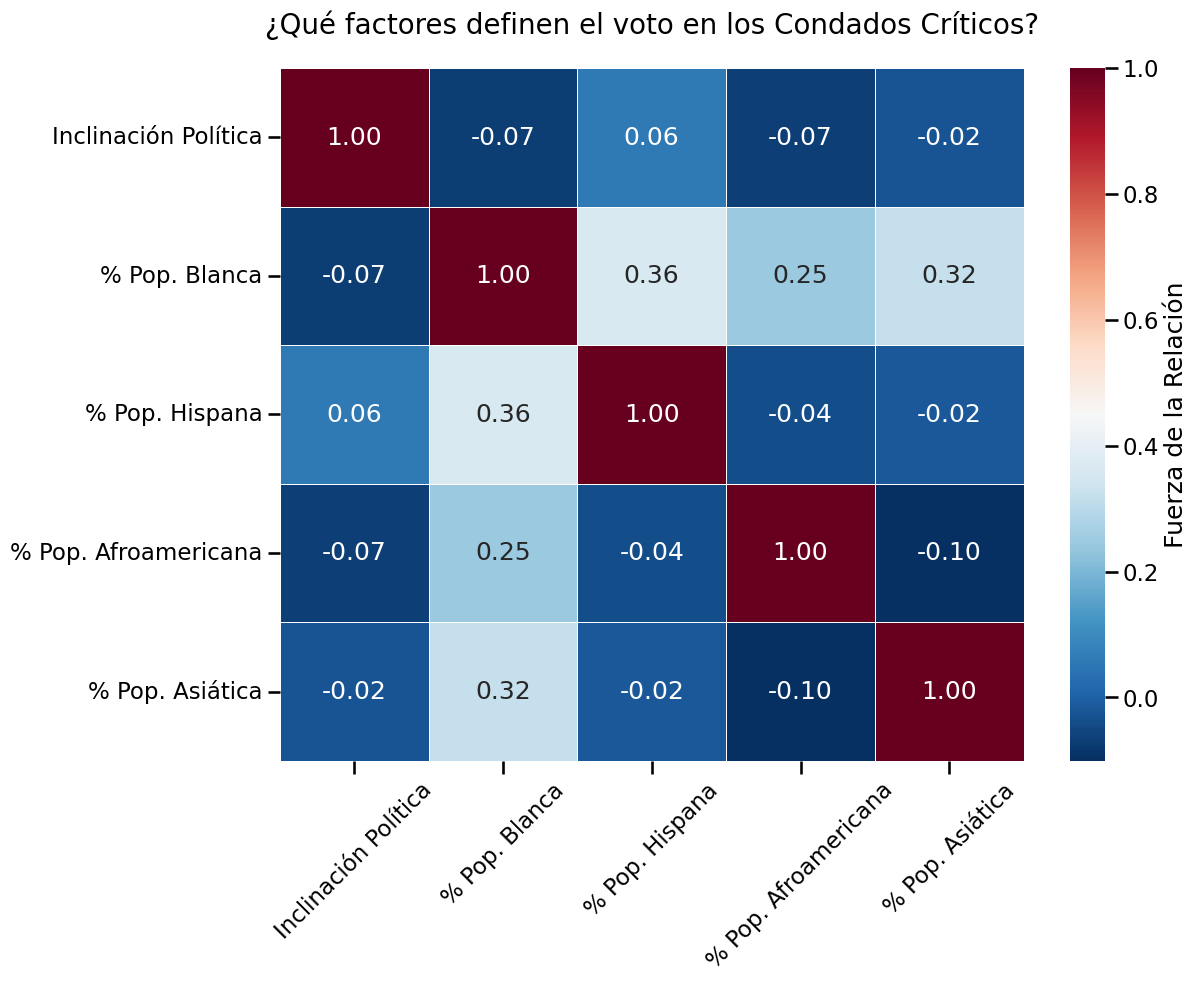

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Renombrar columnas solo para la gráfica (sin afectar tu base de datos)
df_presentacion = df_day4[columnas_interes].rename(columns={
    'margen_perc': 'Inclinación Política',
    'perc_white': '% Pop. Blanca',
    'perc_hispanic': '% Pop. Hispana',
    'perc_black': '% Pop. Afroamericana',
    'perc_asian': '% Pop. Asiática'
})

# 2. Configurar el estilo visual
plt.figure(figsize=(12, 9))
sns.set_context("talk") # Hace que el texto sea más grande para presentaciones

# 3. Crear el Heatmap
heatmap = sns.heatmap(df_presentacion.corr(),
            annot=True,
            cmap='RdBu_r', # Rojo (Republicano) vs Azul (Demócrata)
            fmt=".2f",
            linewidths=.5,
            cbar_kws={'label': 'Fuerza de la Relación'})

# 4. Títulos claros para el cliente
plt.title('¿Qué factores definen el voto en los Condados Críticos?', fontsize=20, pad=25)
plt.xticks(rotation=45)
plt.show()

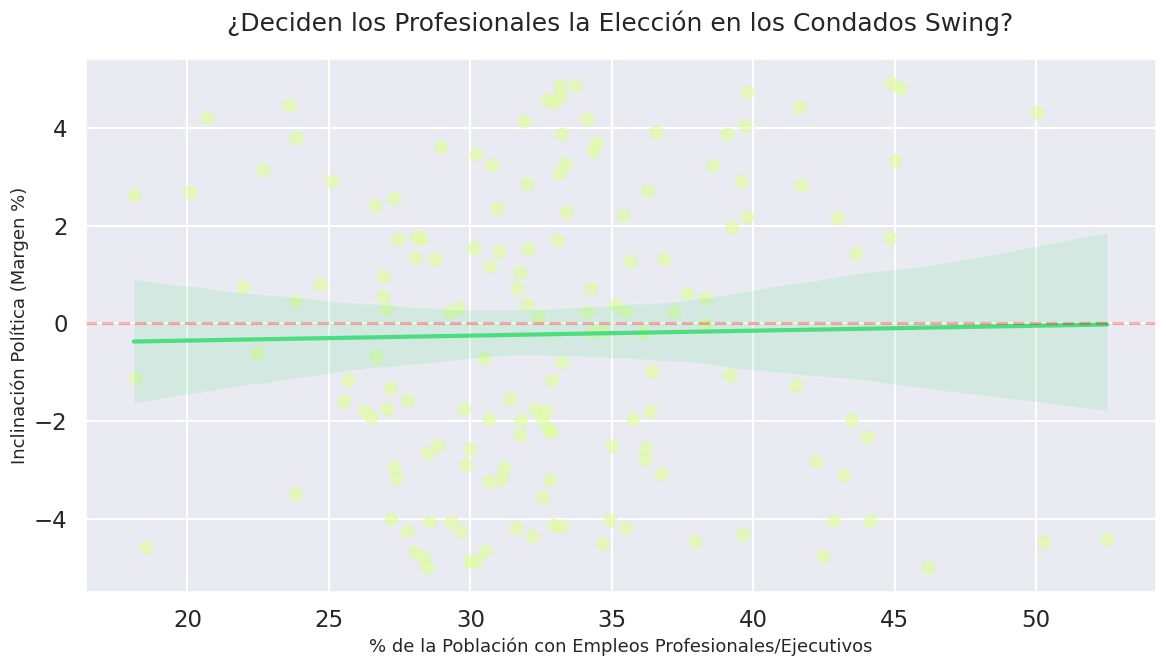

Cruce completado. Condados con datos profesionales: 156


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar el censo desde tu Drive
ruta_censo = '/content/drive/MyDrive/Proyecto_Elecciones_EEUU/acs2015_census_tract_data.csv'
df_census = pd.read_csv(ruta_censo)

# 2. Extraer el FIPS de 5 dígitos desde la columna CensusTract
# El FIPS son los primeros 5 dígitos (o 4 si el código de estado es bajo)
df_census['county_fips'] = df_census['CensusTract'].astype(str).str.zfill(11).str[:5]

# 3. Agrupar el censo por FIPS para obtener el promedio del perfil profesional
df_edu_stats = df_census.groupby('county_fips')['Professional'].mean().reset_index()

# 4. Asegurar que el FIPS en df_day4 sea texto de 5 dígitos para que coincidan
df_day4['county_fips'] = df_day4['county_fips'].astype(str).str.zfill(5)

# 5. Realizar el Cruce Estratégico
df_final_edu = df_day4.merge(df_edu_stats, on='county_fips', how='left')

# 6. Generar la Gráfica para el Cliente
plt.figure(figsize=(12, 7))
sns.set_style("darkgrid")

# Regresión: % Profesional vs Margen Electoral
sns.regplot(data=df_final_edu, x='Professional', y='margen_perc',
            scatter_kws={'color':'#deff9a', 'alpha':0.6},
            line_kws={'color':'#4ade80', 'lw':3})

# Estética ejecutiva
plt.title('¿Deciden los Profesionales la Elección en los Condados Swing?', fontsize=18, pad=20)
plt.xlabel('% de la Población con Empleos Profesionales/Ejecutivos', fontsize=13)
plt.ylabel('Inclinación Política (Margen %)', fontsize=13)
plt.axhline(0, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen de validación
print(f"Cruce completado. Condados con datos profesionales: {df_final_edu['Professional'].notnull().sum()}")

In [13]:
# Guardar el archivo con la nueva columna de educación/profesión
df_final_edu.to_csv('/content/drive/MyDrive/Proyecto_Elecciones_EEUU/df_dia4_consolidado.csv', index=False)
print("✅ Archivo del Día 4 guardado con éxito. ¡Tu base de datos ya es inteligente!")

✅ Archivo del Día 4 guardado con éxito. ¡Tu base de datos ya es inteligente!
